In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import h5py
from xray.func.preprocess import shift_data
from xray.define.backend_data_item import BackendDataItemClass

%matplotlib inline
from xray.define.setting_cfg import load_setting_cfg

cfg = load_setting_cfg()

cfg.efficiency_cfg.shift_pixel

[2025-11-28 17:11:37] [INFO] [xray_log] Called xray.define.setting_cfg.load_setting_cfg(yaml_path='D:\\workspace\\X-Ray\\src\\xray\\setting_cfg.yaml')
[2025-11-28 17:11:37] [INFO] [xray_log] xray.define.setting_cfg.load_setting_cfg finished in 0.0050s
[2025-11-28 17:11:37] [INFO] [xray_log] xray.define.setting_cfg.load_setting_cfg returned result=<type:SettingCfgClass, data:...(truncated)...>


13.0

In [2]:
filepath = r"Z:\labspace\DataCollection\Raw\X-Ray\vplus-data/20251126_Pb_collimator/5Pb_test3_666mmps_1650-1950_110kV_2.7mA_win0_0-119_10s_int20.mat"

os.path.exists(filepath)

True

In [3]:
def get_raw_data(cur_file, pos_unit=0.0375):
    with h5py.File(cur_file, 'r') as f:
        raw_data = f['d']['data'][:]
        pos = f['d']['pos'][:] * pos_unit
        ypos = f['d']['ypos'][:] * pos_unit
        posend = f['d']['posend'][:] * pos_unit
        yposend = f['d']['yposend'][:] * pos_unit
        
        pos_array = np.stack([pos, ypos, posend, yposend], axis=1)[0].T
        
        print(pos_array.shape)
        print(raw_data.shape)
        # pos_array = pos_array.transpose((0, 2, 1))[0]
        # raw_data = raw_data.transpose(3,2,1,0)[:, :, 0, :]
        # raw_data = np.swapaxes(raw_data, 1, 0)  # 再交换轴1和轴0
    return raw_data, pos_array

In [4]:
raw_data, pos_array = get_raw_data(filepath)
raw_recon = raw_data.sum(axis=2)
sid = 670/400
speed = 18.75
frame_time = 2 / 1000

step = speed * frame_time 
pixel_shift = int(1.6 / step / sid) + 3

print(pixel_shift)

shifted_recon = shift_data(raw_recon, pixel_shift)

[2025-11-28 17:11:41] [INFO] [xray_log] Called xray.func.preprocess.shift_data(raw_pixels=<type:ndarray, data:...(truncated)...>, offset_pixel=28)
[2025-11-28 17:11:41] [INFO] [xray_log] xray.func.preprocess.shift_data finished in 0.0174s
[2025-11-28 17:11:41] [INFO] [xray_log] xray.func.preprocess.shift_data returned result=<type:ndarray, data:...(truncated)...>


(5000, 4)
(5000, 256, 120)
28


(1, 256)


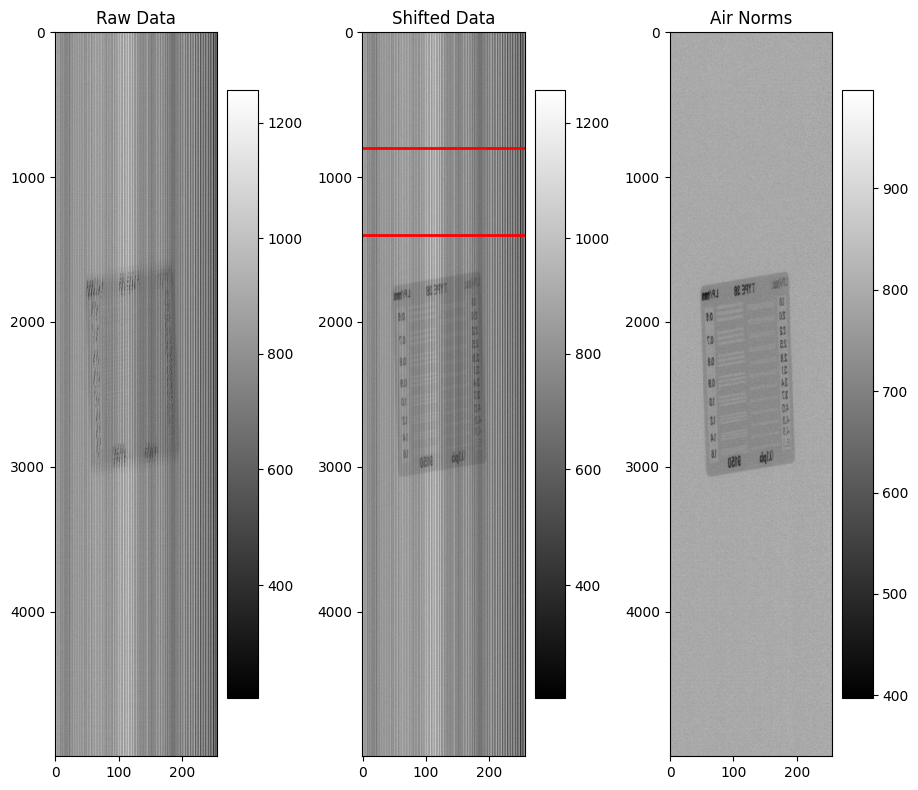

In [5]:
plt.figure(figsize=(12, 8))
plt.subplot(1, 4, 1)
plt.title('Raw Data')
plt.imshow(raw_recon, aspect='auto', cmap='gray')
plt.colorbar()

plt.subplot(1, 4, 2)
plt.title('Shifted Data')
plt.imshow(shifted_recon, aspect='auto', cmap='gray')
plt.colorbar()

plt.axhline(y=800, color="red", linewidth=2)
plt.axhline(y=1400, color="red", linewidth=2)

# plt.axhline(y=6100, color="yellow", linewidth=2)
# plt.axhline(y=6400, color="yellow", linewidth=2)


air_factors = shifted_recon[800: 1600].mean() / shifted_recon[800: 1600].mean(axis=0)[None, :]
print(air_factors.shape)
air_normed = shifted_recon * air_factors

plt.subplot(1, 4, 3)
plt.title('Air Norms')
plt.imshow(air_normed, aspect='auto', cmap='gray')
plt.colorbar()


# board_factors = shifted_recon[6100: 6400].mean() / shifted_recon[6100: 6400].mean(axis=0)[None, :]
# board_normed = shifted_recon * board_factors

# plt.subplot(1, 4, 4)
# plt.title('Board Norms')
# plt.imshow(board_normed, aspect='auto', cmap='gray')
# plt.colorbar()

plt.tight_layout()

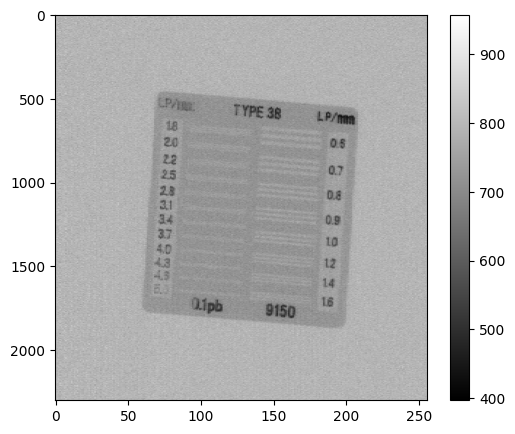

In [6]:
fig = plt.figure(figsize=(6, 5))
plt.imshow(air_normed[1200:3500, ::-1], aspect="auto", cmap="gray")
plt.colorbar()

In [7]:
fig = plt.figure(figsize=(6, 5))
plt.imshow(air_normed[1200:3500, ::-1], aspect="auto", cmap="gray", vmin=500, vmax=834.57060806)
# plt.colorbar()
plt.axis("off")
plt.savefig("air_normed.png",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0)
plt.close()   # 可选：避免后面画图叠加